#Librerias

In [255]:
import seaborn as sns
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt


#Funciones fuzzy

In [256]:
def crear_clase_fuzzy_Low(nombre_clase, offset, **conjuntos):
    """
    Crea y retorna dinámicamente una clase difusa nueva basada en los vectores dados.
    """

    class FuzzyTemplate:
        def __init__(self):
            self.offset = np.array(offset, dtype=float)

            # Guardar los conjuntos difusos
            for nombre, valores in conjuntos.items():
                setattr(self, nombre, np.array(valores, dtype=float))

            # Crear funciones de pertenencia dinámicamente
            for nombre in conjuntos.keys():
                vector = getattr(self, nombre)
                setattr(
                    self,
                    f"mf_{nombre}",
                    lambda x, v=vector: np.interp(
                        x, self.offset, v, left=v[0], right=v[-1]
                    )
                )

        def calcular_offset(self, pv, lmin):
            return float(pv) - float(lmin)

        def evaluar(self, pv, lmin):
            offset = self.calcular_offset(pv, lmin)

            pertenencias = {}
            for nombre in conjuntos.keys():
                mf = getattr(self, f"mf_{nombre}")
                pertenencias[nombre] = float(np.clip(mf(offset), 0, 1))

            dominante = max(pertenencias, key=pertenencias.get)
            valor_dominante = pertenencias[dominante]
            return dominante,valor_dominante, offset, pertenencias

        def graficar(self):
            """Grafica los conjuntos difusos definidos."""
            plt.figure(figsize=(10,5))

            for nombre in conjuntos.keys():
                vector = getattr(self, nombre)
                plt.plot(self.offset, vector, label=nombre, linewidth=2)

            plt.title("Conjuntos difusos generados")
            plt.xlabel("Offset")
            plt.ylabel("Pertenencia")
            plt.grid()
            plt.legend()
            plt.show()

    FuzzyTemplate.__name__ = nombre_clase
    return FuzzyTemplate


def crear_clase_fuzzy_high(nombre_clase, offset, **conjuntos):
    """
    Crea y retorna dinámicamente una clase difusa nueva basada en los vectores dados.
    """

    class FuzzyTemplate:
        def __init__(self):
            self.offset = np.array(offset, dtype=float)

            # Guardar los conjuntos difusos
            for nombre, valores in conjuntos.items():
                setattr(self, nombre, np.array(valores, dtype=float))

            # Crear funciones de pertenencia dinámicamente
            for nombre in conjuntos.keys():
                vector = getattr(self, nombre)
                setattr(
                    self,
                    f"mf_{nombre}",
                    lambda x, v=vector: np.interp(
                        x, self.offset, v, left=v[0], right=v[-1]
                    )
                )

        def calcular_offset(self, pv, lmax):
            return float(lmax) - float(pv)

        def evaluar(self, pv, lmax):
            offset = self.calcular_offset(pv, lmax)

            pertenencias = {}
            for nombre in conjuntos.keys():
                mf = getattr(self, f"mf_{nombre}")
                pertenencias[nombre] = float(np.clip(mf(offset), 0, 1))

            dominante = max(pertenencias, key=pertenencias.get)
            valor_dominante = pertenencias[dominante]
            return dominante,valor_dominante, offset, pertenencias

        def graficar(self):
            """Grafica los conjuntos difusos definidos."""
            plt.figure(figsize=(10,5))

            for nombre in conjuntos.keys():
                vector = getattr(self, nombre)
                plt.plot(self.offset, vector, label=nombre, linewidth=2)

            plt.title("Conjuntos difusos generados")
            plt.xlabel("Offset")
            plt.ylabel("Pertenencia")
            plt.grid()
            plt.legend()
            plt.show()

    FuzzyTemplate.__name__ = nombre_clase
    return FuzzyTemplate

def crear_clase_fuzzy_norm(nombre_clase, offset, **conjuntos):
    """
    Crea y retorna dinámicamente una clase difusa nueva basada en los vectores dados.
    """

    class FuzzyTemplate:
        def __init__(self):
            self.offset = np.array(offset, dtype=float)

            # Guardar los conjuntos difusos
            for nombre, valores in conjuntos.items():
                setattr(self, nombre, np.array(valores, dtype=float))

            # Crear funciones de pertenencia dinámicamente
            for nombre in conjuntos.keys():
                vector = getattr(self, nombre)
                setattr(
                    self,
                    f"mf_{nombre}",
                    lambda x, v=vector: np.interp(
                        x, self.offset, v, left=v[0], right=v[-1]
                    )
                )

        def calcular_offset(self, pv, lmin, lmax):
            return (float(pv) - float(lmin)) / (float(lmax) - float(lmin))

        def evaluar(self, pv, lmin, lmax):
            offset = self.calcular_offset(pv, lmin, lmax)

            pertenencias = {}
            for nombre in conjuntos.keys():
                mf = getattr(self, f"mf_{nombre}")
                pertenencias[nombre] = float(np.clip(mf(offset), 0, 1))

            dominante = max(pertenencias, key=pertenencias.get)
            valor_dominante = pertenencias[dominante]
            return dominante,valor_dominante, offset, pertenencias

        def graficar(self):
            """Grafica los conjuntos difusos definidos."""
            plt.figure(figsize=(10,5))

            for nombre in conjuntos.keys():
                vector = getattr(self, nombre)
                plt.plot(self.offset, vector, label=nombre, linewidth=2)

            plt.title("Conjuntos difusos generados")
            plt.xlabel("Offset")
            plt.ylabel("Pertenencia")
            plt.grid()
            plt.legend()
            plt.show()

    FuzzyTemplate.__name__ = nombre_clase
    return FuzzyTemplate

def crear_clase_fuzzy_pendiente(nombre_clase, x, **conjuntos):
    """
    Template dinámico para crear clases de pendiente difusa.

    Parámetros:
        nombre_clase (str): Nombre de la clase a generar.
        x (list/array): Dominio de la pendiente.
        conjuntos: Diccionario de vectores difusos (subiendo, estable, bajando, etc.)
    """

    class FuzzyPendienteTemplate:
        def __init__(self):
            self.x = np.array(x, dtype=float)

            # Guardar dinámicamente los conjuntos difusos
            for nombre, valores in conjuntos.items():
                setattr(self, nombre, np.array(valores, dtype=float))

            # Crear funciones de pertenencia dinámicamente
            for nombre in conjuntos.keys():
                vector = getattr(self, nombre)
                setattr(
                    self,
                    f"mf_{nombre}",
                    lambda p, v=vector: np.interp(
                        p, self.x, v, left=v[0], right=v[-1]
                    )
                )

        def evaluar(self, pendiente):
            """
            Evalúa una pendiente real y devuelve:
            (conjunto dominante, valor, pertenencias, inferencia)
            """
            p = float(pendiente)
            pertenencias = {}

            # Calcular todas las pertenencias
            for nombre in conjuntos.keys():
                mf = getattr(self, f"mf_{nombre}")
                pertenencias[nombre] = float(np.clip(mf(p), 0, 1))

            # Conjunto dominante
            dominante = max(pertenencias, key=pertenencias.get)

            # Valor de inferencia = grado del dominante
            inferencia = pertenencias[dominante]

            return dominante, p, pertenencias, inferencia

    FuzzyPendienteTemplate.__name__ = nombre_clase
    return FuzzyPendienteTemplate

#Modelos difusos

In [257]:

# ==============================================================
# 2) CREAR LOS MODELOS DIFUSOS QUE USARÁ EL SISTEMA EXPERTO
# ==============================================================

PotMolBolas = crear_clase_fuzzy_Low(
    "pot_mol_bolas",
    offset=[-10, 0, 10, 20, 40, 60, 70, 80],
    bajo=[0, 0, 0, 0.5, 1, 1, 1, 1],
    OK=[0, 0.5, 1, 0.5, 0, 0, 0, 0],
    alto=[1, 0.5, 0, 0, 0, 0, 0, 0]
)
fuzzy_pot_bolas = PotMolBolas()


PotSag1 = crear_clase_fuzzy_high(
    "pot_sag1",
    offset=[-10, 0, 10, 20, 40, 60, 70, 80],
    bajo=[0, 0, 0, 0.5, 1, 1, 1, 1],
    OK=[0, 0.5, 1, 0.5, 0, 0, 0, 0],
    alto=[1, 0.5, 0, 0, 0, 0, 0, 0]
)
fuzzy_pot_sag1 = PotSag1()


FuzzyNivel1 = crear_clase_fuzzy_norm(
    "fuzzy_nivel1",
    offset=[-1.1, -1, 0, 0.5, 0.7, 0.8, 1.0, 1.1],
    bajo=[0, 0, 0, 0.5, 1, 1, 1, 1],
    OK=[0, 0.5, 1, 0.5, 0, 0, 0, 0],
    alto=[1, 0.5, 0, 0, 0, 0, 0, 0]
)
fuzzy_nivel1 = FuzzyNivel1()


PendienteGeneral = crear_clase_fuzzy_pendiente(
    "PendienteGeneral",
    x=[-20, -10, -5, 0, 5, 10, 20],
    subiendo=[1, 1, 0.5, 0, 0, 0, 0],
    estable=[0, 0, 0.5, 1, 0.5, 0, 0],
    bajando=[0, 0, 0, 0, 0.5, 1, 1]
)
fuzzy_pend = PendienteGeneral()

P80Model = crear_clase_fuzzy_high(
    "p80_model",
    offset=[-20, 0, 20, 40, 60, 80, 100, 120],
    bajo=[1, 0.5, 0, 0, 0, 0, 0, 0],      # P80 muy bajo = sobre molienda
    OK=[0, 0.5, 1, 0.5, 0, 0, 0, 0],       # objetivo
    alto=[0, 0, 0, 0.5, 1, 1, 1, 1]        # P80 alto = problema
)
fuzzy_p80 = P80Model()

PresionModel = crear_clase_fuzzy_high(
    "presion_model",
    offset=[-5, 0, 5, 10, 20, 30, 40, 50],
    bajo=[1, 0.5, 0, 0, 0, 0, 0, 0],
    OK=[0, 0.5, 1, 0.5, 0, 0, 0, 0],
    alto=[0, 0, 0, 0.5, 1, 1, 1, 1]
)
fuzzy_presion = PresionModel()

DensidadModel = crear_clase_fuzzy_high(
    "densidad_model",
    offset=[-10, 0, 10, 20, 30, 40, 50, 60],
    bajo=[1, 0.5, 0, 0, 0, 0, 0, 0],
    OK=[0, 0.5, 1, 0.5, 0, 0, 0, 0],
    alto=[0, 0, 0, 0.5, 1, 1, 1, 1]
)
fuzzy_densidad = DensidadModel()


# ==============================================================
# 3) FUNCIÓN ÚNICA PARA LLAMAR A TODOS LOS MODELOS
# ==============================================================

def evaluar_fuzzy(
    pv_bolas, lmin_bolas,
    pv_sag, lmax_sag,
    pv_nivel, lmin_nivel, lmax_nivel,
    pv_p80, lmax_p80,
    pv_pres, lmax_pres,
    pv_dens, lmax_dens,
):

    # ------------------------
    #  Fuzzy principales
    # ------------------------
    dom_bolas, val_bolas, off_bolas, pert_bolas = fuzzy_pot_bolas.evaluar(pv_bolas, lmin_bolas)
    dom_sag, val_sag, off_sag, pert_sag = fuzzy_pot_sag1.evaluar(pv_sag, lmax_sag)
    dom_nivel, val_nivel, off_nivel, pert_nivel = fuzzy_nivel1.evaluar(pv_nivel, lmin_nivel, lmax_nivel)

    dom_p80, val_p80, off_p80, pert_p80 = fuzzy_p80.evaluar(pv_p80, lmax_p80)
    dom_pres, val_pres, off_pres, pert_pres = fuzzy_presion.evaluar(pv_pres, lmax_pres)
    dom_dens, val_dens, off_dens, pert_dens = fuzzy_densidad.evaluar(pv_dens, lmax_dens)

    # ------------------------
    #  Retorno estructurado
    # ------------------------
    return {
        "pot_bolas": {
            "dom": dom_bolas, "val": val_bolas, "offset": off_bolas, "pert": pert_bolas},

        "pot_sag": {
            "dom": dom_sag, "val": val_sag, "offset": off_sag, "pert": pert_sag
                   },

        "nivel": {
            "dom": dom_nivel, "val": val_nivel, "offset": off_nivel, "pert": pert_nivel},

        "p80": {
            "dom": dom_p80, "val": val_p80, "offset": off_p80, "pert": pert_p80,
        },

        "presion": {
            "dom": dom_pres, "val": val_pres, "offset": off_pres, "pert": pert_pres},

        "densidad": {
            "dom": dom_dens, "val": val_dens, "offset": off_dens, "pert": pert_dens,}
    }

result = evaluar_fuzzy(
    pv_bolas=720, lmin_bolas=700,
    pv_sag=21, lmax_sag=24,
    pv_nivel=65, lmin_nivel=50, lmax_nivel=70,

    pv_p80=180, lmax_p80=300,
    pv_pres=12, lmax_pres=25,
    pv_dens=1.35, lmax_dens=1.60,


)

result

{'pot_bolas': {'dom': 'bajo',
  'val': 0.5,
  'offset': 20.0,
  'pert': {'bajo': 0.5, 'OK': 0.5, 'alto': 0.0}},
 'pot_sag': {'dom': 'OK',
  'val': 0.65,
  'offset': 3.0,
  'pert': {'bajo': 0.0, 'OK': 0.65, 'alto': 0.35}},
 'nivel': {'dom': 'bajo',
  'val': 1.0,
  'offset': 0.75,
  'pert': {'bajo': 1.0, 'OK': 0.0, 'alto': 0.0}},
 'p80': {'dom': 'alto',
  'val': 1.0,
  'offset': 120.0,
  'pert': {'bajo': 0.0, 'OK': 0.0, 'alto': 1.0}},
 'presion': {'dom': 'alto',
  'val': 0.65,
  'offset': 13.0,
  'pert': {'bajo': 0.0, 'OK': 0.35, 'alto': 0.65}},
 'densidad': {'dom': 'OK',
  'val': 0.5125,
  'offset': 0.25,
  'pert': {'bajo': 0.4875, 'OK': 0.5125, 'alto': 0.0}}}

#Evaluar condicion

In [258]:
def evaluar_condicion(signal_fuzzy, condicion):
    """
    Evalúa condiciones tipo:
      - 'ALTO'
      - 'OK'
      - 'BAJO'
      - 'NO-ALTO'
      - 'NO-OK'
      - 'NO-BAJO'
    """
    condicion = condicion.upper().strip()

    # Caso NO-XXXX
    if condicion.startswith("NO-"):
        target = condicion.replace("NO-", "").lower()
        return signal_fuzzy["dom"] != target

    # Caso normal
    return signal_fuzzy["dom"] == condicion.lower()


In [259]:
print("¿P80 ALTO?", evaluar_condicion(result["p80"], "ALTO"))
print("¿P80 NO-ALTO?", evaluar_condicion(result["p80"], "NO-ALTO"))
print("¿Presión ALTA?", evaluar_condicion(result["presion"], "ALTO"))
print("¿Nivel NO-ALTO?", evaluar_condicion(result["nivel"], "NO-ALTO"))
print("¿Densidad BAJA?", evaluar_condicion(result["densidad"], "BAJO"))


¿P80 ALTO? True
¿P80 NO-ALTO? False
¿Presión ALTA? True
¿Nivel NO-ALTO? True
¿Densidad BAJA? False


#Reglas

In [260]:
# ==============================================================
# ESTRUCTURA DE REGLAS DEL SISTEMA EXPERTO DE MOLIENDA-CLASIFICACIÓN
# Basado 100% en tu tabla de reglas
# ==============================================================

REGLAS = {
    "molino_cargado": [],        # prioridad 1
    "cajon_alto": [],            # prioridad 2
    "p80_alto": [],              # prioridad 3
    "optimizar_potencia": [],    # prioridad 4
    "p80_no_alto": [],           # prioridad 5
    "densidad_presion": [],      # prioridad 6
    "presion_baja": []           # prioridad 7
}


# ==============================================================
# BLOQUE 1 — MOLINO CARGADO (Reglas 1–4)
# ==============================================================

REGLAS["molino_cargado"] += [

    {
        "id": 1,
        "descripcion": "Potencia ALTA, Nivel NO-ALTO, P80 NO-ALTO",
        "si": [
            ("pot_sag", "ALTO"),
            ("nivel", "NO-ALTO"),
            ("p80", "NO-ALTO")
        ],
        "accion": "aumentar_agua_molino_disminuir_agua_cajon",
        "duracion": 20,
        "prioridad": 1
    },

    {
        "id": 2,
        "descripcion": "Potencia ALTA, Nivel ALTO, P80 NO-ALTO",
        "si": [
            ("pot_sag", "ALTO"),
            ("nivel", "ALTO"),
            ("p80", "NO-ALTO")
        ],
        "accion": "disminuir_agua_cajon",
        "duracion": 20,
        "prioridad": 1
    },

    {
        "id": 3,
        "descripcion": "Potencia ALTA, Nivel NO-ALTO, P80 ALTO",
        "si": [
            ("pot_sag", "ALTO"),
            ("nivel", "NO-ALTO"),
            ("p80", "ALTO")
        ],
        "accion": "aumentar_agua_molino",
        "duracion": 20,
        "prioridad": 1
    },

    {
        "id": 4,
        "descripcion": "Potencia ALTA, Nivel ALTO, P80 ALTO",
        "si": [
            ("pot_sag", "ALTO"),
            ("nivel", "ALTO"),
            ("p80", "ALTO")
        ],
        "accion": "disminuir_agua_cajon",
        "duracion": 20,
        "prioridad": 1
    }
]


# ==============================================================
# BLOQUE 2 — CAJÓN ALTO (Reglas 5–7)
# ==============================================================

REGLAS["cajon_alto"] += [

    {
        "id": 5,
        "descripcion": "Nivel ALTO, Presión NO-ALTA",
        "si": [
            ("nivel", "ALTO"),
            ("presion", "NO-ALTO")
        ],
        "accion": "disminuir_agua_cajon",
        "duracion": 20,
        "prioridad": 2
    },

    {
        "id": 6,
        "descripcion": "Nivel ALTO, Presión ALTA, P80 NO-ALTO",
        "si": [
            ("nivel", "ALTO"),
            ("presion", "ALTO"),
            ("p80", "NO-ALTO")
        ],
        "accion": "aumentar_agua_molino",
        "duracion": 20,
        "prioridad": 2
    },

    {
        "id": 7,
        "descripcion": "Nivel ALTO, Presión ALTA, P80 ALTO",
        "si": [
            ("nivel", "ALTO"),
            ("presion", "ALTO"),
            ("p80", "ALTO")
        ],
        "accion": "disminuir_tonelaje",
        "duracion": 20,
        "prioridad": 2
    }
]


# ==============================================================
# BLOQUE 3 — P80 ALTO (Reglas 8–9)
# ==============================================================

REGLAS["p80_alto"] += [

    {
        "id": 8,
        "descripcion": "P80 ALTO, Presión NO-BAJA",
        "si": [
            ("p80", "ALTO"),
            ("presion", "NO-BAJO")
        ],
        "accion": "aumentar_agua_ciclones",
        "duracion": 20,
        "prioridad": 3
    },

    {
        "id": 9,
        "descripcion": "P80 ALTO, Presión BAJA",
        "si": [
            ("p80", "ALTO"),
            ("presion", "BAJO")
        ],
        "accion": "aumentar_tonelaje",
        "duracion": 20,
        "prioridad": 3
    }
]


# ==============================================================
# BLOQUE 4 — OPTIMIZAR POTENCIA (Reglas 10–12)
# ==============================================================

REGLAS["optimizar_potencia"] += [

    {
        "id": 10,
        "descripcion": "Potencia OK, cerca de ALTO",
        "si": [
            ("pot_sag", "OK")
        ],
        "accion": "aumentar_tonelaje",
        "duracion": 120,
        "prioridad": 4
    },

    {
        "id": 11,
        "descripcion": "Potencia OK",
        "si": [
            ("pot_sag", "OK")
        ],
        "accion": "mantener",
        "duracion": 120,
        "prioridad": 4
    },

    {
        "id": 12,
        "descripcion": "Potencia OK, varianza BAJA",
        "si": [
            ("pot_sag", "OK")
        ],
        "accion": "aumentar_tonelaje",
        "duracion": 120,
        "prioridad": 4
    }
]


# ==============================================================
# BLOQUE 5 — P80 NO ALTO (Regla 13)
# ==============================================================

REGLAS["p80_no_alto"] += [
    {
        "id": 13,
        "descripcion": "P80 NO-ALTO",
        "si": [
            ("p80", "NO-ALTO")
        ],
        "accion": "aumentar_tonelaje",
        "duracion": 20,
        "prioridad": 5
    }
]


# ==============================================================
# BLOQUE 6 — DENSIDAD / PRESIÓN (Reglas 14–16)
# ==============================================================

REGLAS["densidad_presion"] += [

    {
        "id": 14,
        "descripcion": "Densidad ALTA",
        "si": [
            ("densidad", "ALTA")
        ],
        "accion": "disminuir_tonelaje",
        "duracion": 20,
        "prioridad": 6
    },

    {
        "id": 15,
        "descripcion": "Densidad OK y Presión ALTA",
        "si": [
            ("densidad", "OK"),
            ("presion", "ALTO")
        ],
        "accion": "aumentar_agua_ciclones",
        "duracion": 20,
        "prioridad": 6
    },

    {
        "id": 16,
        "descripcion": "Densidad BAJA",
        "si": [
            ("densidad", "BAJO")
        ],
        "accion": "disminuir_agua_ciclones",
        "duracion": 20,
        "prioridad": 6
    }
]


# ==============================================================
# BLOQUE 7 — PRESIÓN BAJA (Reglas 17–18)
# ==============================================================

REGLAS["presion_baja"] += [

    {
        "id": 17,
        "descripcion": "Presión BAJA",
        "si": [
            ("presion", "BAJO")
        ],
        "accion": "aumentar_tonelaje",
        "duracion": 20,
        "prioridad": 7
    },

    {
        "id": 18,
        "descripcion": "Presión BAJA, Densidad ALTA",
        "si": [
            ("presion", "BAJO"),
            ("densidad", "ALTO")
        ],
        "accion": "disminuir_tonelaje",
        "duracion": 20,
        "prioridad": 7
    }
]



#Motor de reglas con Esperas/Anti-SPAM

In [261]:

cooldowns = {}
def regla_en_cooldown(regla):
    rid = regla["id"]
    if rid not in cooldowns:
        return False
    return time.time() < cooldowns[rid]
def motor_reglas(result, reglas):
    """
    Evalúa las reglas en orden de prioridad y respeta el cooldown.
    Devuelve la primera regla verdadera disponible.
    """

    for bloque_nombre, lista_reglas in reglas.items():
        for regla in lista_reglas:

            # ----------------------------
            # 1) ¿La regla está en cooldown?
            # ----------------------------
            if regla_en_cooldown(regla):
                continue  # saltarla y probar la siguiente

            # ----------------------------
            # 2) Evaluar condiciones fuzzy
            # ----------------------------
            condiciones_cumplidas = True
            for variable, cond_texto in regla["si"]:
                if not evaluar_condicion(result[variable], cond_texto):
                    condiciones_cumplidas = False
                    break

            # ----------------------------
            # 3) Activar regla si corresponde
            # ----------------------------
            if condiciones_cumplidas:
                # registrar cooldown
                cooldowns[regla["id"]] = time.time() + regla["duracion"]

                return {
                    "regla_activada": regla["id"],
                    "bloque": bloque_nombre,
                    "descripcion": regla["descripcion"],
                    "accion": regla["accion"],
                    "duracion": regla["duracion"],
                    "cooldown_hasta": cooldowns[regla["id"]]
                }

    # Si ninguna regla se activa
    return {
        "regla_activada": None,
        "accion": "sin_accion",
        "duracion": 0,
        "descripcion": "No se activó ninguna regla"
    }
import datetime

def mostrar_cooldowns(reglas, cooldowns):
    """
    Muestra el estado de cooldown de todas las reglas:
    - si están activas
    - cuánto tiempo falta
    - fecha/hora en que se liberan
    """

    ahora = time.time()
    print("\n==========================")
    print(" ESTADO DE COOLDOWNS")
    print("==========================\n")

    # recorrer todos los bloques y reglas
    for bloque, lista_reglas in reglas.items():
        print(f"--- BLOQUE: {bloque.upper()} ---")

        for regla in lista_reglas:
            rid = regla["id"]

            if rid not in cooldowns:
                print(f"Regla {rid}: disponible")
                continue

            fin = cooldowns[rid]

            if ahora >= fin:
                print(f"Regla {rid}: disponible (cooldown expirado)")
            else:
                restante = fin - ahora
                hora_fin = datetime.datetime.fromtimestamp(fin)
                print(
                    f"Regla {rid}: EN COOLDOWN "
                    f"({restante:.1f} s restantes → hasta {hora_fin.strftime('%Y-%m-%d %H:%M:%S')})"
                )

        print()  # salto de bloque


In [262]:
result = evaluar_fuzzy(
    pv_bolas=750, lmin_bolas=700,
    pv_sag=21, lmax_sag=24,
    pv_nivel=65, lmin_nivel=50, lmax_nivel=70,
    pv_p80=180, lmax_p80=300,
    pv_pres=12, lmax_pres=25,
    pv_dens=1.35, lmax_dens=1.60,
)
salida1 = motor_reglas(result, REGLAS)
salida1


{'regla_activada': 8,
 'bloque': 'p80_alto',
 'descripcion': 'P80 ALTO, Presión NO-BAJA',
 'accion': 'aumentar_agua_ciclones',
 'duracion': 20,
 'cooldown_hasta': 1764448345.3285823}

In [263]:
mostrar_cooldowns(REGLAS, cooldowns)



 ESTADO DE COOLDOWNS

--- BLOQUE: MOLINO_CARGADO ---
Regla 1: disponible
Regla 2: disponible
Regla 3: disponible
Regla 4: disponible

--- BLOQUE: CAJON_ALTO ---
Regla 5: disponible
Regla 6: disponible
Regla 7: disponible

--- BLOQUE: P80_ALTO ---
Regla 8: EN COOLDOWN (20.0 s restantes → hasta 2025-11-29 20:32:25)
Regla 9: disponible

--- BLOQUE: OPTIMIZAR_POTENCIA ---
Regla 10: disponible
Regla 11: disponible
Regla 12: disponible

--- BLOQUE: P80_NO_ALTO ---
Regla 13: disponible

--- BLOQUE: DENSIDAD_PRESION ---
Regla 14: disponible
Regla 15: disponible
Regla 16: disponible

--- BLOQUE: PRESION_BAJA ---
Regla 17: disponible
Regla 18: disponible



#Dashboard de Depuración

In [264]:
def explicar_decision(result, salida_motor):


    if salida_motor["regla_activada"] is None:
        print("⚠ No se activó ninguna regla.\n")
        return

    print("\n==============================")
    print("     EXPLICACIÓN DE DECISIÓN  ")
    print("==============================\n")

    print(f"📌 Regla activada: {salida_motor['regla_activada']}")
    print(f"📁 Bloque: {salida_motor['bloque']}")
    print(f"📝 Descripción: {salida_motor['descripcion']}")
    print(f"🎯 Acción recomendada: {salida_motor['accion']}")
    print(f"⏳ Tiempo mínimo antes de repetir: {salida_motor['duracion']} segundos\n")

    print("---- VARIABLES QUE GATILLARON LA REGLA ----")

    # Recuperar la regla original:
    regla = None
    for r in REGLAS[salida_motor["bloque"]]:
        if r["id"] == salida_motor["regla_activada"]:
            regla = r
            break

    # Explicar cada condición
    for variable, cond in regla["si"]:
        fuzzy = result[variable]
        dom = fuzzy["dom"]
        val = fuzzy["val"]
        off = fuzzy["offset"]

        print(f"\n▶ {variable.upper()}")
        print(f"  - Condición pedida: {cond}")
        print(f"  - Valor difuso dominante: {dom} (fuerza {val:.2f})")
        print(f"  - Offset: {off}")
        print(f"  - Pertenencias: {fuzzy['pert']}")

    print("\n--------------------------------------------")
    print("✔ El sistema eligió esta regla porque TODAS las condiciones se cumplieron.\n")

def graficar_fuzzy_variable(nombre, fuzzy_class, valor_offset):
    """
    Grafica un fuzzy y marca el valor actual.
    """

    x = fuzzy_class.offset
    plt.figure(figsize=(5,3))

    for label in [k for k in fuzzy_class.__dict__ if not k.startswith("mf_") and k not in ["offset"]]:
        y = getattr(fuzzy_class, label)
        plt.plot(x, y, label=label, linewidth=2)

    # marcar valor actual
    plt.axvline(valor_offset, color="red", linestyle="--")
    plt.title(f"Fuzzy {nombre} (offset={valor_offset})")
    plt.xlabel("Offset")
    plt.ylabel("Pertenencia")
    plt.legend()
    plt.grid(True)
    plt.show()

def dashboard_fuzzy(result):
    print("\n==============================")
    print("        DASHBOARD FUZZY        ")
    print("==============================\n")

    # Potencia Molino Bolas
    graficar_fuzzy_variable("Potencia Molino Bolas", fuzzy_pot_bolas, result["pot_bolas"]["offset"])

    # Potencia SAG
    graficar_fuzzy_variable("Potencia SAG", fuzzy_pot_sag1, result["pot_sag"]["offset"])

    # Nivel
    graficar_fuzzy_variable("Nivel", fuzzy_nivel1, result["nivel"]["offset"])

    # P80
    graficar_fuzzy_variable("P80", fuzzy_p80, result["p80"]["offset"])

    # Presión
    graficar_fuzzy_variable("Presión", fuzzy_presion, result["presion"]["offset"])

    # Densidad
    graficar_fuzzy_variable("Densidad", fuzzy_densidad, result["densidad"]["offset"])



     EXPLICACIÓN DE DECISIÓN  

📌 Regla activada: 8
📁 Bloque: p80_alto
📝 Descripción: P80 ALTO, Presión NO-BAJA
🎯 Acción recomendada: aumentar_agua_ciclones
⏳ Tiempo mínimo antes de repetir: 20 segundos

---- VARIABLES QUE GATILLARON LA REGLA ----

▶ P80
  - Condición pedida: ALTO
  - Valor difuso dominante: alto (fuerza 1.00)
  - Offset: 120.0
  - Pertenencias: {'bajo': 0.0, 'OK': 0.0, 'alto': 1.0}

▶ PRESION
  - Condición pedida: NO-BAJO
  - Valor difuso dominante: alto (fuerza 0.65)
  - Offset: 13.0
  - Pertenencias: {'bajo': 0.0, 'OK': 0.35, 'alto': 0.65}

--------------------------------------------
✔ El sistema eligió esta regla porque TODAS las condiciones se cumplieron.


        DASHBOARD FUZZY        



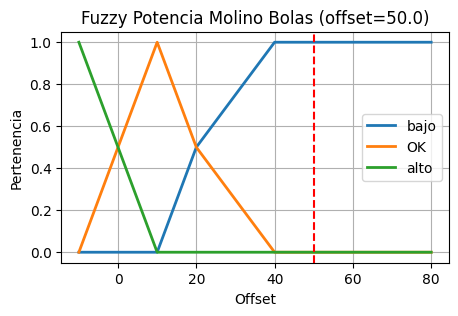

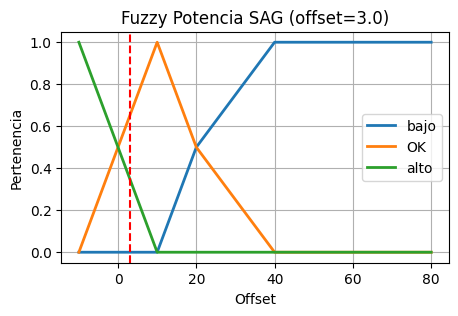

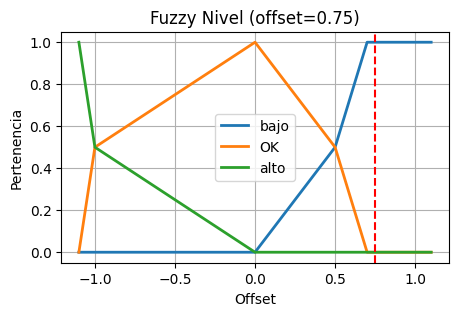

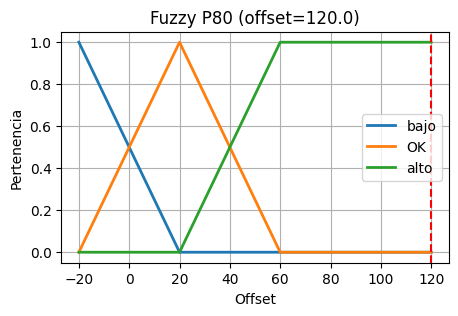

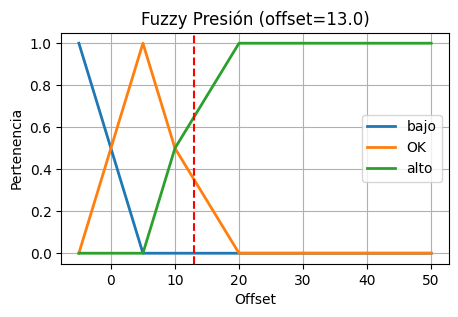

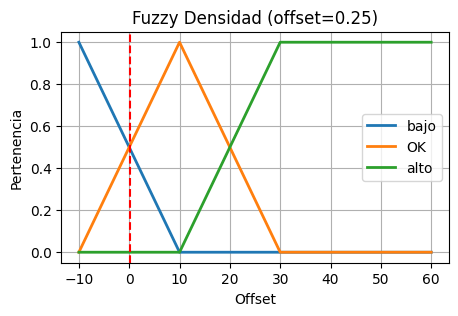

In [276]:
def dashboard_completo(result,salida, reglas):
    explicar_decision(result, salida)
    dashboard_fuzzy(result)
    return salida

salida = dashboard_completo(result,salida1, REGLAS)


#Panel de depuración

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


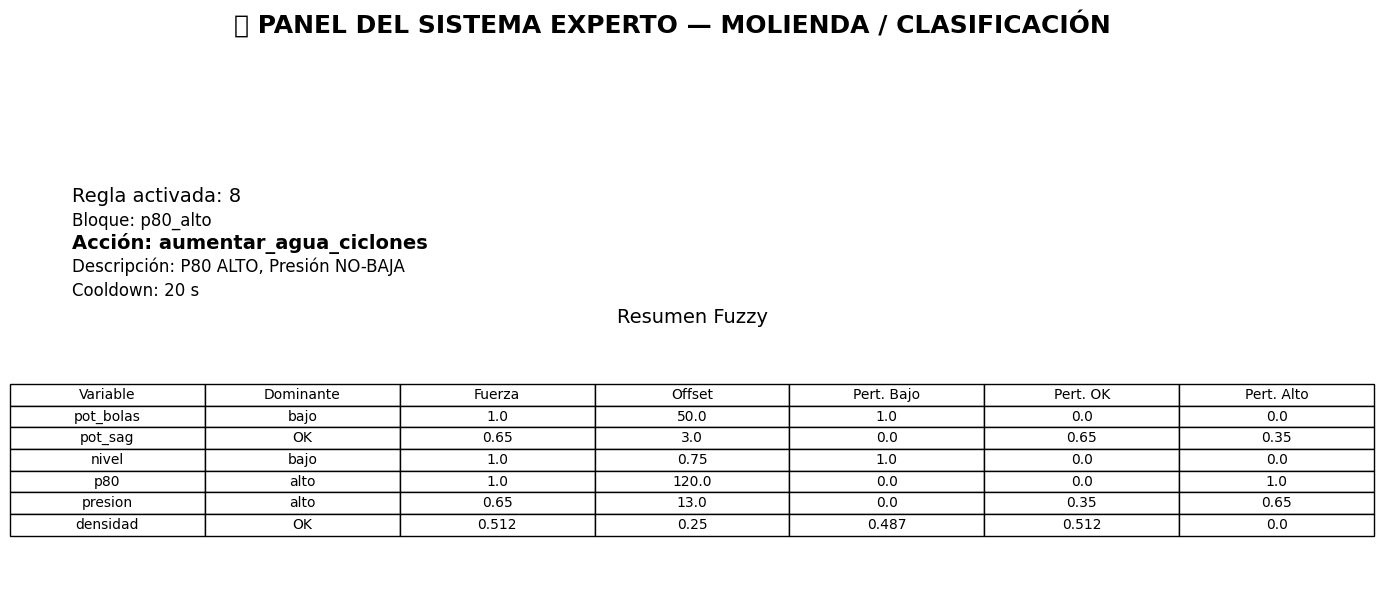

In [277]:

def resumen_fuzzy(result):
    filas = []

    for var, data in result.items():
        filas.append({
            "Variable": var,
            "Dominante": data["dom"],
            "Fuerza": round(data["val"], 3),
            "Offset": round(data["offset"], 3),
            "Pert. Bajo": round(data["pert"].get("bajo", 0), 3),
            "Pert. OK": round(data["pert"].get("OK", 0), 3),
            "Pert. Alto": round(data["pert"].get("alto", 0), 3),
        })

    return pd.DataFrame(filas)
def plot_fuzzy_subplot(ax, fuzzy_class, valor_offset, titulo):
    x = fuzzy_class.offset
    ax.set_title(titulo, fontsize=9)

    for label in [k for k in fuzzy_class.__dict__
                  if not k.startswith("mf_") and k not in ["offset"]]:
        y = getattr(fuzzy_class, label)
        ax.plot(x, y, label=label)

    ax.axvline(valor_offset, color="red", linestyle="--", linewidth=1)

    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, linestyle="--", alpha=0.3)
import matplotlib.pyplot as plt

def panel_sistema_experto(result, salida_motor):
    df = resumen_fuzzy(result)

    fig = plt.figure(figsize=(16, 18))
    fig.suptitle("📊 PANEL DEL SISTEMA EXPERTO — MOLIENDA / CLASIFICACIÓN", fontsize=18, fontweight="bold")

    # ----------- Sección 1: Texto principal -----------
    ax1 = plt.subplot2grid((10,4), (0,0), colspan=4, rowspan=1)
    ax1.axis("off")

    if salida_motor["regla_activada"] is None:
        ax1.text(0, 0.9, "⚠ No se activó ninguna regla", fontsize=14, color="red")
    else:
        ax1.text(0, 0.9, f"Regla activada: {salida_motor['regla_activada']}", fontsize=14)
        ax1.text(0, 0.7, f"Bloque: {salida_motor['bloque']}", fontsize=12)
        ax1.text(0, 0.5, f"Acción: {salida_motor['accion']}", fontsize=14, fontweight="bold")
        ax1.text(0, 0.3, f"Descripción: {salida_motor['descripcion']}", fontsize=12)
        ax1.text(0, 0.1, f"Cooldown: {salida_motor['duracion']} s", fontsize=12)

    # ----------- Sección 2: Tabla resumen -----------
    ax2 = plt.subplot2grid((10,4), (1,0), colspan=4, rowspan=2)
    ax2.axis("off")
    ax2.set_title("Resumen Fuzzy", fontsize=14)

    tabla = ax2.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc='center',
        loc='center'
    )
    tabla.auto_set_font_size(False)
    tabla.set_fontsize(10)
    tabla.scale(1.1, 1.3)

panel_sistema_experto(result, salida)

#Integracion con DF

In [267]:
def evaluar_fila(row):
    result = evaluar_fuzzy(
        pv_bolas=row["pot_bolas"], lmin_bolas=row["lmin_bolas"],
        pv_sag=row["pot_sag"],     lmax_sag=row["lmax_sag"],
        pv_nivel=row["nivel"],     lmin_nivel=row["lmin_nivel"], lmax_nivel=row["lmax_nivel"],
        pv_p80=row["p80"],         lmax_p80=row["lmax_p80"],
        pv_pres=row["presion"],    lmax_pres=row["lmax_pres"],
        pv_dens=row["densidad"],   lmax_dens=row["lmax_dens"]
    )

    salida = motor_reglas(result, REGLAS)

    return {
        "regla": salida["regla_activada"],
        "bloque": salida.get("bloque", None),
        "accion": salida["accion"],
        "descripcion": salida["descripcion"],
    }

def aplicar_sistema_experto(df):
    registros = []

    for idx, row in df.iterrows():
        salida = evaluar_fila(row)
        registro = salida.copy()
        registro["timestamp"] = idx
        registros.append(registro)

    return pd.DataFrame(registros)

df = pd.DataFrame({
    "pot_bolas": [700, 750, 760],
    "lmin_bolas": [700, 700, 700],
    "pot_sag": [20, 22, 24],
    "lmax_sag": [24, 24, 24],
    "nivel": [10, 50, 80],
    "lmin_nivel": [60, 50, 50],
    "lmax_nivel": [70, 70, 70],
    "p80": [100, 180, 100],
    "lmax_p80": [300, 300, 300],
    "presion": [12, 14, 18],
    "lmax_pres": [25, 25, 25],
    "densidad": [1.30, 1.35, 1.40],
    "lmax_dens": [1.60, 1.60, 1.60],
})
df_acciones = aplicar_sistema_experto(df)
df_acciones


,regla,bloque,accion,descripcion,timestamp
0,7.0,cajon_alto,disminuir_tonelaje,"Nivel ALTO, Presión ALTA, P80 ALTO",0
1,NaN,None,sin_accion,No se activó ninguna regla,1
2,NaN,None,sin_accion,No se activó ninguna regla,2


#Defuzzy

In [268]:
ACCIONES_FISICAS = {
    "aumentar_tonelaje": 10,       # ton/h
    "disminuir_tonelaje": -10,     # ton/h
    "aumentar_agua_molino": 5,     # m3/h
    "disminuir_agua_molino": -5,   # m3/h
    "aumentar_agua_cajon": 4,
    "disminuir_agua_cajon": -4,
    "aumentar_agua_ciclones": 6,
    "disminuir_agua_ciclones": -6,
    "mantener": 0
}
def fuerza_de_regla(result, regla):
    fuerzas = []

    for var, cond in regla["si"]:
        fuerzas.append(result[var]["val"])

    return min(fuerzas)
def defuzzy(result, salida_motor):
    if salida_motor["regla_activada"] is None:
        return {"accion_fisica": 0, "comentario": "sin acción"}

    # localizar la regla dentro del bloque
    regla = None
    for r in REGLAS[salida_motor["bloque"]]:
        if r["id"] == salida_motor["regla_activada"]:
            regla = r
            break

    fuerza = fuerza_de_regla(result, regla)

    accion = salida_motor["accion"]
    max_step = ACCIONES_FISICAS[accion]

    # step final = fuerza * max_step
    step = fuerza * max_step

    return {
        "accion": accion,
        "fuerza": fuerza,
        "step": step,
        "unidad": "ton/h" if "tonelaje" in accion else "m3/h"
    }


In [269]:
salida = motor_reglas(result, REGLAS)

defuzzy(result, salida)


{'accion_fisica': 0, 'comentario': 'sin acción'}

#SIMULACION

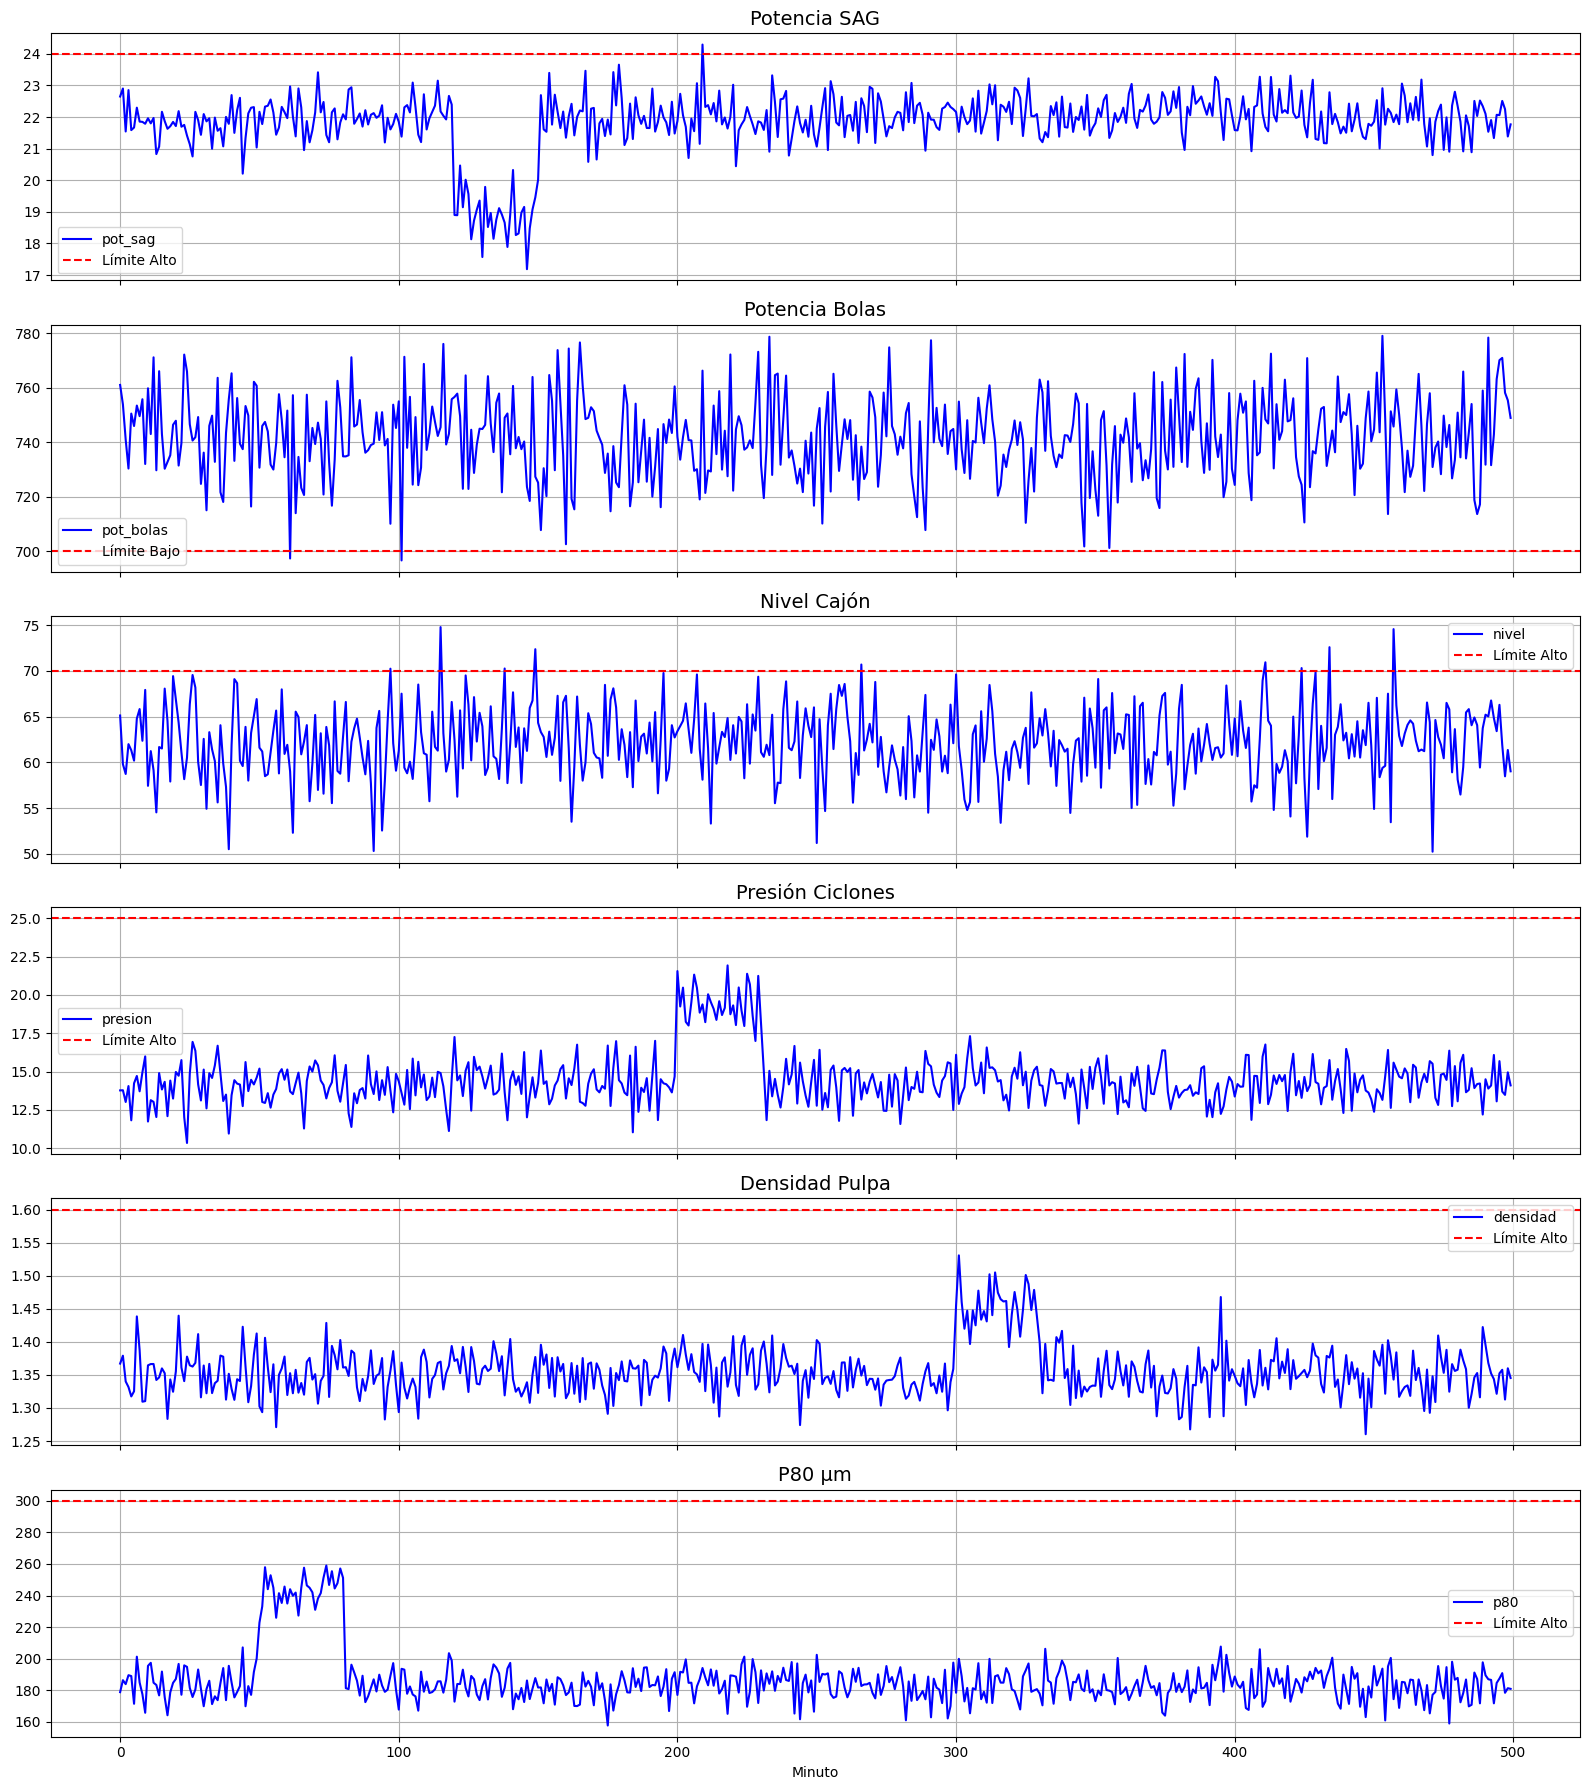

In [270]:
np.random.seed(42)

N = 500  # número de minutos simulados

df = pd.DataFrame()

# Tonelaje base (no lo usamos en fuzzy, pero sirve para coherencia)
df["tonelaje"] = 1400 + np.random.normal(0, 30, N)

# Potencia SAG correlacionada al tonelaje
df["pot_sag"] = 22 + (df["tonelaje"] - 1400) / 80 + np.random.normal(0, 0.5, N)
df["lmax_sag"] = 24  # límite fijo

# Potencia Bolas (ruido moderado)
df["pot_bolas"] = 740 + np.random.normal(0, 15, N)
df["lmin_bolas"] = 700

# Nivel del cajón (ruido + correlación con agua ciclones)
df["nivel"] = 62 + np.random.normal(0, 4, N)
df["lmin_nivel"] = 50
df["lmax_nivel"] = 70

# Presión de ciclones correlacionada a tonelaje, nivel y densidad
df["presion"] = 14 + (df["tonelaje"] - 1400) / 200 + (df["nivel"] - 60) / 10 + np.random.normal(0, 1.2, N)
df["lmax_pres"] = 25

# Densidad correlacionada al P80 y presión
df["densidad"] = 1.35 + np.random.normal(0, 0.03, N)
df["lmax_dens"] = 1.60

# P80 correlacionado a densidad y presión
df["p80"] = 180 + (df["densidad"] - 1.35) * 200 - (df["presion"] - 15) * 4 + np.random.normal(0, 5, N)
df["lmax_p80"] = 300

# Ajustar valores fuera de rango
df["pot_sag"] = df["pot_sag"].clip(18, 26)
df["nivel"] = df["nivel"].clip(45, 80)
df["presion"] = df["presion"].clip(5, 25)
df["densidad"] = df["densidad"].clip(1.20, 1.50)
df["p80"] = df["p80"].clip(100, 280)
# ================================
# FORZAR EVENTOS PARA ACTIVAR REGLAS
# ================================

# Evento 1 – P80 muy alto (molienda gruesa)
df.loc[50:80, "p80"] += 60

# Evento 2 – Potencia SAG baja (carga baja o tapón)
df.loc[120:150, "pot_sag"] -= 3

# Evento 3 – Presión muy alta (sobrecarga ciclones)
df.loc[200:230, "presion"] += 5

# Evento 4 – Densidad muy alta (agua insuficiente)
df.loc[300:330, "densidad"] += 0.10

# Clip para evitar valores irreales
df["pot_sag"] = df["pot_sag"].clip(16, 26)
df["presion"] = df["presion"].clip(5, 25)
df["densidad"] = df["densidad"].clip(1.20, 1.60)
df["p80"] = df["p80"].clip(100, 350)

df.head()
import matplotlib.pyplot as plt

fig, axes = plt.subplots(6, 1, figsize=(16, 18), sharex=True)
variables = [
    ("pot_sag", "lmax_sag", "Potencia SAG"),
    ("pot_bolas", "lmin_bolas", "Potencia Bolas"),
    ("nivel", "lmax_nivel", "Nivel Cajón"),
    ("presion", "lmax_pres", "Presión Ciclones"),
    ("densidad", "lmax_dens", "Densidad Pulpa"),
    ("p80", "lmax_p80", "P80 µm"),
]

for ax, (var, lim, titulo) in zip(axes, variables):

    ax.plot(df[var], label=var, color="blue")

    # dibujar limite
    if "lmin" in lim:
        ax.axhline(df[lim].iloc[0], color="red", linestyle="--", label="Límite Bajo")
    else:
        ax.axhline(df[lim].iloc[0], color="red", linestyle="--", label="Límite Alto")

    ax.set_title(titulo, fontsize=14)
    ax.grid(True)
    ax.legend()

plt.xlabel("Minuto")
plt.tight_layout()
plt.show()


In [271]:

# =====================================================================
# MOTOR DE REGLAS — COMPATIBLE CON LA ESTRUCTURA ORIGINAL
# =====================================================================

# Diccionario global que guarda el último tiempo en que cada regla se disparó
ultima_activacion = {}   # ejemplo: {"1": 125, ...}

def motor_reglas(resultados_fuzzy, REGLAS, tiempo_actual):
    """
    result_fuzzy: salida de evaluar_fuzzy()
    REGLAS: diccionario de bloques de reglas (tal como lo definiste)
    tiempo_actual: tiempo simulado en SEGUNDOS
    ------------------------------------------------------------
    Devuelve:
        - regla activada (id)
        - bloque
        - acción sugerida
        - descripción
        - cooldown aplicado
    """

    # =========================================================
    # ORDENAMOS BLOQUES POR PRIORIDAD GLOBAL (1 a 7)
    # =========================================================
    bloques_ordenados = sorted(
        REGLAS.items(),
        key=lambda x: x[1][0]["prioridad"] if len(x[1]) > 0 else 999
    )

    # =========================================================
    # RECORRER BLOQUE POR BLOQUE (PRIORIDAD)
    # =========================================================
    for nombre_bloque, reglas in bloques_ordenados:

        for regla in reglas:

            regla_id = regla["id"]
            condiciones = regla["si"]
            cooldown_sec = regla["duracion"]

            # ------------------------------------------
            # 1) cooldown
            # ------------------------------------------
            t_ultima = ultima_activacion.get(regla_id, -999999)

            if tiempo_actual < t_ultima:
                continue   # aún no puede actuar

            # ------------------------------------------
            # 2) validar condiciones fuzzy
            # ------------------------------------------
            cumple = True

            for var, esperado in condiciones:
                dom = resultados_fuzzy[var]["dom"].upper()

                if esperado != dom:
                    cumple = False
                    break

            # ------------------------------------------
            # 3) si cumple todo → activar regla
            # ------------------------------------------
            if cumple:
                ultima_activacion[regla_id] = tiempo_actual + cooldown_sec

                return {
                    "regla_activada": regla_id,
                    "bloque": nombre_bloque,
                    "accion": regla["accion"],
                    "descripcion": regla["descripcion"],
                    "cooldown_hasta": ultima_activacion[regla_id]
                }

    # ------------------------------------------------------------
    # SIN REGLA ACTIVADA
    # ------------------------------------------------------------
    return {
        "regla_activada": None,
        "bloque": None,
        "accion": None,
        "descripcion": None,
        "cooldown_hasta": None
    }


In [272]:
def tick(variables, tiempo_actual):
    """
    Un ciclo del sistema experto cada 5 segundos.
    """

    # 1) Fuzzy
    result = evaluar_fuzzy(
        pv_bolas=variables["pot_bolas"], lmin_bolas=variables["lmin_bolas"],
        pv_sag=variables["pot_sag"],     lmax_sag=variables["lmax_sag"],
        pv_nivel=variables["nivel"],     lmin_nivel=variables["lmin_nivel"], lmax_nivel=variables["lmax_nivel"],
        pv_p80=variables["p80"],         lmax_p80=variables["lmax_p80"],
        pv_pres=variables["presion"],    lmax_pres=variables["lmax_pres"],
        pv_dens=variables["densidad"],   lmax_dens=variables["lmax_dens"]
    )

    # 2) Motor de reglas (usa tiempo simulado en segundos)
    salida_motor = motor_reglas(result, REGLAS, tiempo_actual)

    # 3) Defuzzy
    accion_real = defuzzy(result, salida_motor)

    return {
        "fuzzy": result,
        "regla": salida_motor,
        "accion_fisica": accion_real
    }


In [273]:
historial = []

tiempo_simulado = 0          # segundos
SCAN = 5                     # intervalo de control = 5 segundos

for i in range(len(df)):
    vars_proceso = df.iloc[i].to_dict()

    salida_tick = tick(vars_proceso, tiempo_simulado)

    acc = salida_tick.get("accion_fisica", {})

    historial.append({
        "tiempo_s": tiempo_simulado,
        "regla": salida_tick["regla"].get("regla_activada", None),
        "bloque": salida_tick["regla"].get("bloque", None),
        "accion": acc.get("accion", None),
        "step": acc.get("step", 0),
        "fuerza": acc.get("fuerza", 0),
    })

    tiempo_simulado += SCAN

df_historial = pd.DataFrame(historial)
display(df_historial)


,tiempo_s,regla,bloque,accion,step,fuerza
0,0,10.0,optimizar_potencia,aumentar_tonelaje,5.675322,0.567532
1,5,11.0,optimizar_potencia,mantener,0.000000,0.554857
2,10,12.0,optimizar_potencia,aumentar_tonelaje,6.228200,0.622820
3,15,15.0,densidad_presion,aumentar_agua_ciclones,3.080510,0.513418
4,20,NaN,None,None,0.000000,0.000000
...,...,...,...,...,...,...
495,2475,NaN,None,None,0.000000,0.000000
496,2480,15.0,densidad_presion,aumentar_agua_ciclones,3.072680,0.512113
497,2485,NaN,None,None,0.000000,0.000000
498,2490,NaN,None,None,0.000000,0.000000


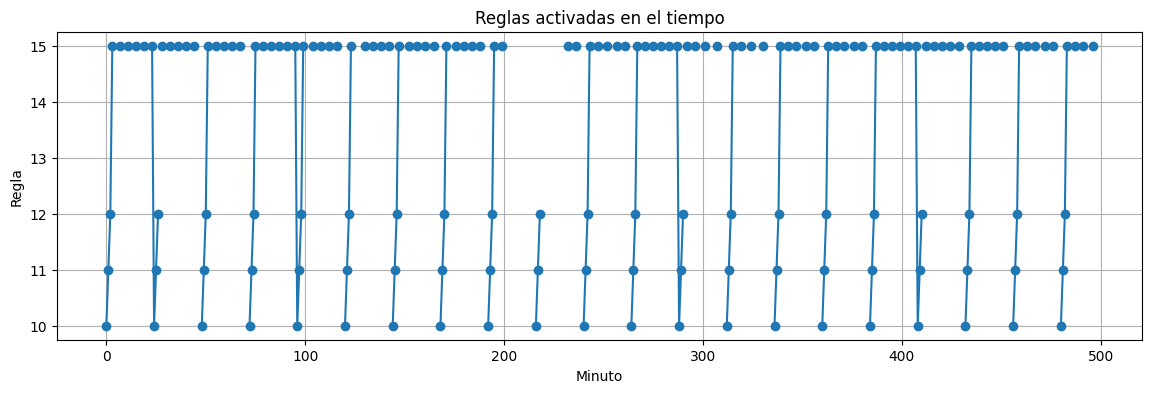

In [274]:

plt.figure(figsize=(14,4))
plt.plot(df_historial["regla"], marker='o')
plt.title("Reglas activadas en el tiempo")
plt.xlabel("Minuto")
plt.ylabel("Regla")
plt.grid(True)
plt.show()


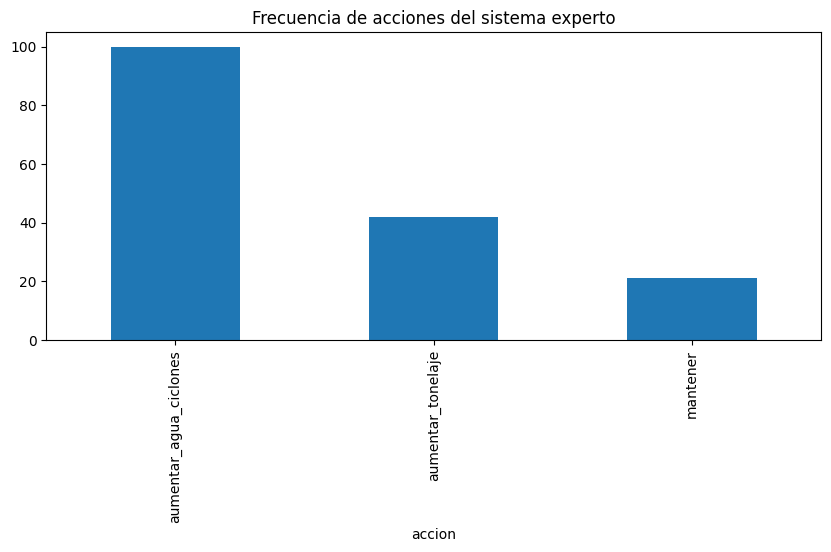

In [275]:
df_historial["accion"].value_counts().plot(kind="bar", figsize=(10,4))
plt.title("Frecuencia de acciones del sistema experto")
plt.show()
